# Convoluzione in 1 dimensione



Formula della convoluzione:

$$
(x * w) (t) = \int_{\mathbb{R}} x (a) w ( t - a) da
$$

Librerie necessarie:
- `pytorch` 
    - https://pytorch.org/
    - https://docs.pytorch.org/docs/stable/index.html
- `numpy`
- `matplotlib`
- `pandas`
- `sklearn`

Importiamo un dataset di segnali

In [1]:
import pandas as pd

df = pd.read_csv('./data/impulse_signals_dataset_noisy.csv')

print(f"Forma del dataset: {df.shape}")
print(f"Etichette: {df['label'].value_counts().sort_index().to_dict()}")
print(f"Prime righe del dataset:")
print(df.head())

Forma del dataset: (100, 101)
Etichette: {0: 50, 1: 50}
Prime righe del dataset:
   sample_0  sample_1  sample_2  sample_3  sample_4  sample_5  sample_6  \
0  0.533244  0.063765 -0.111172  0.233782 -0.388833 -0.451825 -0.124500   
1  0.680498 -0.273103 -0.082953 -0.016866  0.427883 -0.470229 -0.017530   
2 -0.605237 -0.096722  0.791618 -0.488681  0.474882 -0.379172  0.506545   
3 -0.378475 -0.104757 -0.132834 -0.307253 -0.054325  0.028585 -0.137793   
4 -0.283796 -0.177090  0.090724 -0.015698 -0.423678 -0.187335  0.294203   

   sample_7  sample_8  sample_9  ...  sample_91  sample_92  sample_93  \
0 -0.215139  0.865890  0.625630  ...   0.341346   0.063777   0.780611   
1  0.204740  0.060936  0.591921  ...   0.195613  -0.062478   0.016067   
2 -0.279370 -0.198860  0.528466  ...   0.615318   0.018300  -0.038567   
3 -0.418027  0.261175 -0.137493  ...  -0.254342   0.233732  -0.247300   
4  0.157897  0.069271 -0.455359  ...  -0.216296  -0.188830   0.495759   

   sample_94  sample_95  samp

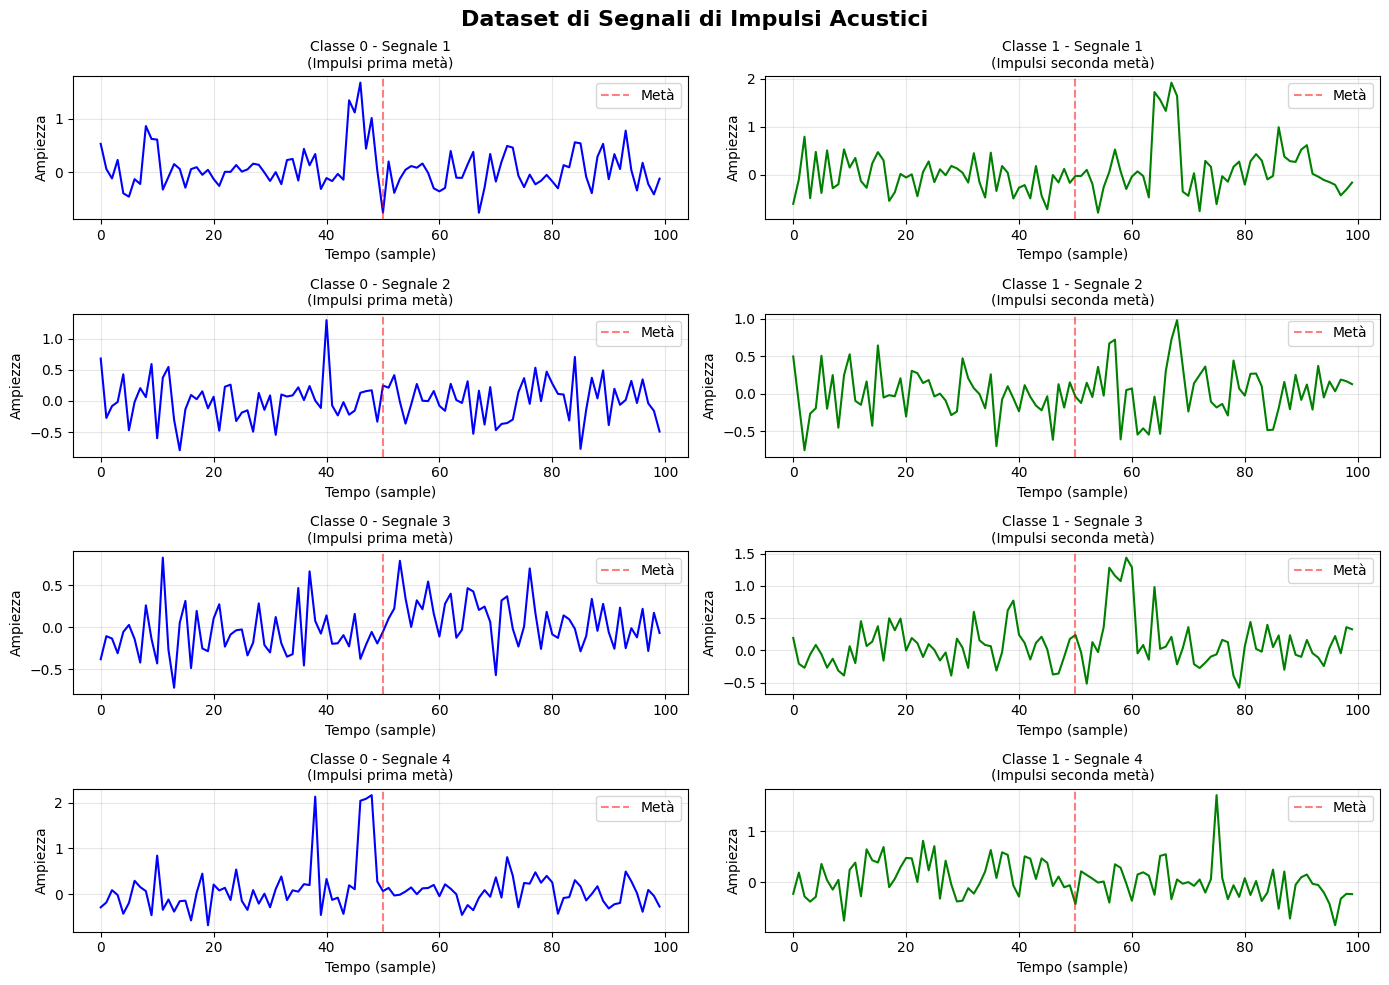

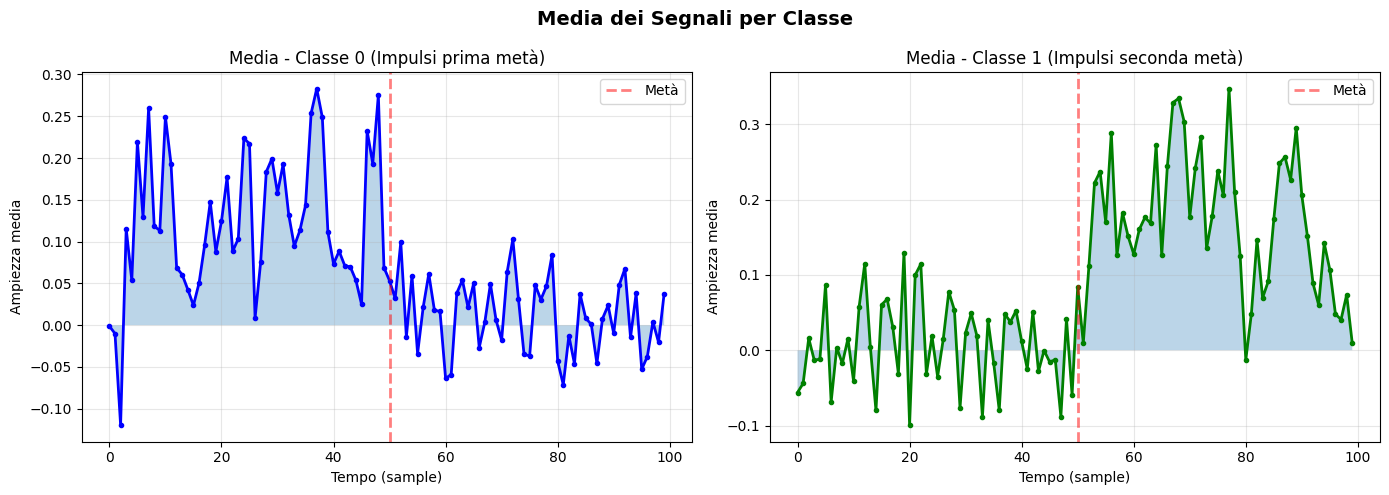

Statistiche del dataset:
Classe 0 - Media: 0.0680, Std: 0.4394
Classe 1 - Media: 0.0875, Std: 0.4532


In [2]:
import visualize_impulse_signals

### Creare un MLP per classificare i dati

L'MLP deve avere un solo strato nascosto, un input layer di 100 neuroni e un output layer con 2 uscite, una per classe.

In [72]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size=100, hidden_size=64, num_classes=2):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model = MLP(input_size=100, hidden_size=64, num_classes=2)

Importare il dataset per l'uso con MLP

In [73]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split


X = df.drop('label', axis=1).values
y = df['label'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)

X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)


train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

Definire una loss e un ottimizzatore, poi addestrare l'MLP.

In [74]:
criterion = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


epochs = 10
for epoch in range(epochs):
    for X_batch, y_batch in train_loader:
        
        # azzerare i gradienti
        optimizer.zero_grad()
        
        # passo forward
        outputs = model(X_batch)
        
        # passo backward
        y_batch_onehot = torch.nn.functional.one_hot(y_batch, num_classes=2).float()
        loss = criterion(outputs, y_batch_onehot)
        loss.backward()
        
        # discesa del gradiente (aggiornamento dei pesi)
        optimizer.step()
    
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


with torch.no_grad():
    y_pred = model(X_test).argmax(dim=1)
    accuracy = (y_pred == y_test).float().mean()
    print(f'Test Accuracy: {accuracy.item():.4f}')

Epoch [1/10], Loss: 0.3670
Epoch [2/10], Loss: 0.3103
Epoch [3/10], Loss: 0.2898
Epoch [4/10], Loss: 0.2807
Epoch [5/10], Loss: 0.2116
Epoch [6/10], Loss: 0.2454
Epoch [7/10], Loss: 0.1904
Epoch [8/10], Loss: 0.2305
Epoch [9/10], Loss: 0.1707
Epoch [10/10], Loss: 0.1839
Test Accuracy: 0.7000


### Convoluzione dei segnali in ingresso

Definire due kernel di dimensione 5 per la convoluzione: filtro di media e filtro gaussiano.

Applicare i due kernel a 5 esempi di segnali in ingresso presenti nel training set, e visualizzare i risultati.

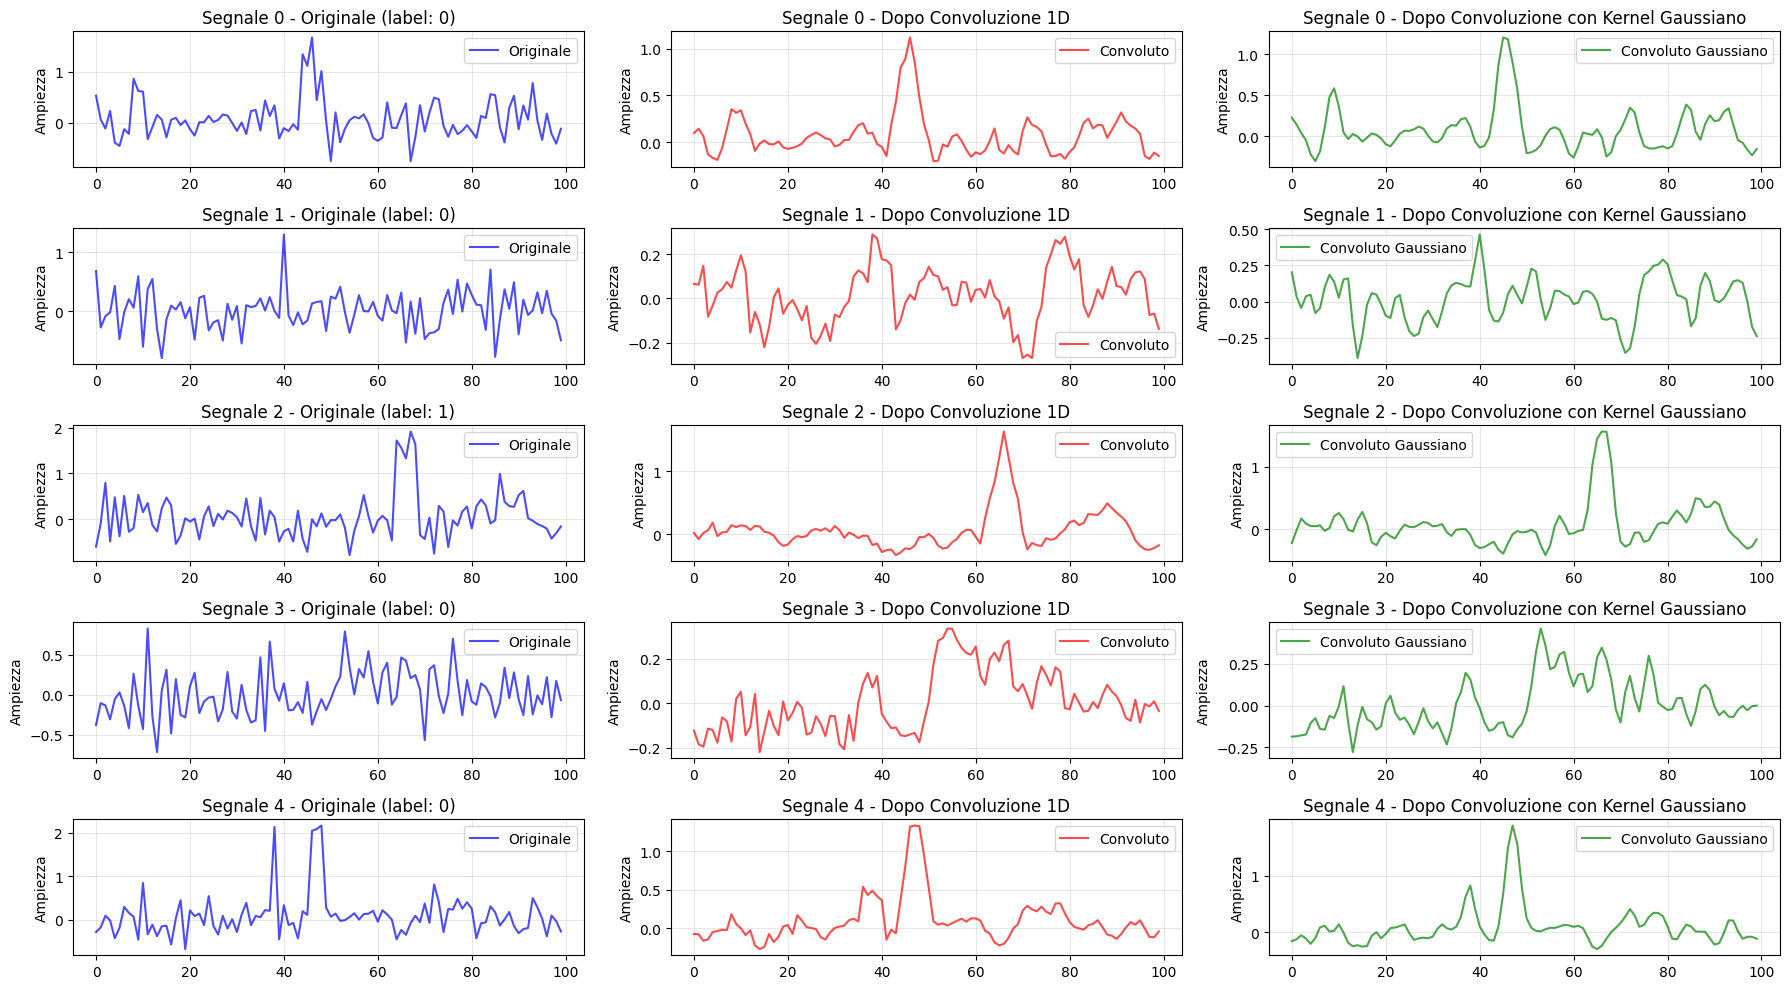

In [75]:
import numpy as np

import matplotlib.pyplot as plt

kernel = np.ones(5) / 5  # kernel per media mobile

sigma = 1.0
x = np.linspace(-2, 2, 5)
gaussian_kernel = np.exp(-x**2 / (2 * sigma**2))
gaussian_kernel /= gaussian_kernel.sum()  # Normalize


fig, axes = plt.subplots(5, 3, figsize=(18, 10))

for i in range(5):
    signal = df.iloc[i, :-1].values
    
    signal_convolved = np.convolve(signal, kernel, mode='same')

    gaussian_signal = np.convolve(signal, gaussian_kernel, mode='same')
    
    # Visualizza il segnale originale
    axes[i, 0].plot(signal, label='Originale', color='blue', alpha=0.7)
    axes[i, 0].set_title(f'Segnale {i} - Originale (label: {df.iloc[i, -1]})')
    axes[i, 0].set_ylabel('Ampiezza')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)
    
    # Visualizza il segnale dopo convoluzione
    axes[i, 1].plot(signal_convolved, label='Convoluto', color='red', alpha=0.7)
    axes[i, 1].set_title(f'Segnale {i} - Dopo Convoluzione 1D')
    axes[i, 1].set_ylabel('Ampiezza')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

    # Visualizza il segnale dopo convoluzione con kernel gaussiano
    axes[i, 2].plot(gaussian_signal, label='Convoluto Gaussiano', color='green', alpha=0.7)
    axes[i, 2].set_title(f'Segnale {i} - Dopo Convoluzione con Kernel Gaussiano')
    axes[i, 2].set_ylabel('Ampiezza')
    axes[i, 2].legend()
    axes[i, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Effettuare la convoluzione con kernel di media su tutto il dataset di training e di testing, poi addestrare lo stesso MLP di prima sui nuovi dataset.

In [76]:
np.random.seed(42)

torch.manual_seed(42)

X_train_np = X_train.numpy()
X_test_np = X_test.numpy()

X_train_convolved_np = np.array([np.convolve(signal, kernel, mode='same') for signal in X_train_np])
X_test_convolved_np = np.array([np.convolve(signal, kernel, mode='same') for signal in X_test_np])


X_train_convolved = torch.FloatTensor(X_train_convolved_np)
X_test_convolved = torch.FloatTensor(X_test_convolved_np)


train_dataset_convolved = TensorDataset(X_train_convolved, y_train)
train_loader_convolved = DataLoader(train_dataset_convolved, batch_size=8, shuffle=True)


model_convolved = MLP(input_size=100, hidden_size=64, num_classes=2)
criterion_convolved = nn.MSELoss()
optimizer_convolved = torch.optim.SGD(model_convolved.parameters(), lr=0.01)

epochs = 10
for epoch in range(epochs):
    for X_batch, y_batch in train_loader_convolved:

        optimizer_convolved.zero_grad()

        outputs = model_convolved(X_batch)

        y_batch_onehot = torch.nn.functional.one_hot(y_batch, num_classes=2).float()
        loss = criterion_convolved(outputs, y_batch_onehot)
        
        loss.backward()

        optimizer_convolved.step()
    
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


with torch.no_grad():
    y_pred_convolved = model_convolved(X_test_convolved).argmax(dim=1)
    accuracy_convolved = (y_pred_convolved == y_test).float().mean()
    print(f'Test Accuracy (Convolved): {accuracy_convolved.item():.4f}')

Epoch [1/10], Loss: 0.3758
Epoch [2/10], Loss: 0.3410
Epoch [3/10], Loss: 0.3303
Epoch [4/10], Loss: 0.2703
Epoch [5/10], Loss: 0.2725
Epoch [6/10], Loss: 0.2423
Epoch [7/10], Loss: 0.2130
Epoch [8/10], Loss: 0.2028
Epoch [9/10], Loss: 0.1932
Epoch [10/10], Loss: 0.1755
Test Accuracy (Convolved): 0.8000


Effettuare la convoluzione con kernel gaussiano su tutto il dataset di training e di testing, poi addestrare lo stesso MLP di prima sui nuovi dataset.

In [77]:
np.random.seed(42)

torch.manual_seed(42)

X_train_gaussian_np = np.array([np.convolve(signal, gaussian_kernel, mode='same') for signal in X_train_np])
X_test_gaussian_np = np.array([np.convolve(signal, gaussian_kernel, mode='same') for signal in X_test_np])

X_train_gaussian = torch.FloatTensor(X_train_gaussian_np)
X_test_gaussian = torch.FloatTensor(X_test_gaussian_np)

train_dataset_gaussian = TensorDataset(X_train_gaussian, y_train)
train_loader_gaussian = DataLoader(train_dataset_gaussian, batch_size=8, shuffle=True)


model_gaussian = MLP(input_size=100, hidden_size=64, num_classes=2)
criterion_gaussian = nn.MSELoss()
optimizer_gaussian = torch.optim.SGD(model_gaussian.parameters(), lr=0.01)

epochs = 10
for epoch in range(epochs):
    for X_batch, y_batch in train_loader_gaussian:

        optimizer_gaussian.zero_grad()

        outputs = model_gaussian(X_batch)

        y_batch_onehot = torch.nn.functional.one_hot(y_batch, num_classes=2).float()
        loss = criterion_gaussian(outputs, y_batch_onehot)
        
        loss.backward()
        optimizer_gaussian.step()
    
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


with torch.no_grad():
    y_pred_gaussian = model_gaussian(X_test_gaussian).argmax(dim=1)
    accuracy_gaussian = (y_pred_gaussian == y_test).float().mean()
    print(f'Test Accuracy (Gaussian Convolved): {accuracy_gaussian.item():.4f}')

Epoch [1/10], Loss: 0.3734
Epoch [2/10], Loss: 0.3304
Epoch [3/10], Loss: 0.3100
Epoch [4/10], Loss: 0.2693
Epoch [5/10], Loss: 0.2596
Epoch [6/10], Loss: 0.2289
Epoch [7/10], Loss: 0.2020
Epoch [8/10], Loss: 0.1968
Epoch [9/10], Loss: 0.1804
Epoch [10/10], Loss: 0.1701
Test Accuracy (Gaussian Convolved): 0.8500
